<a href="https://colab.research.google.com/github/chizkidd/deep-learning-models/blob/main/pytorch/resnet50-cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torch.amp import GradScaler, autocast

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")


Num GPUs Available:  1
GPU 0: Tesla T4


---
# ResNet: Residual Blocks
---

- <u>**Single Residual Block:**</u>
The fundamental innovation of a Residual Block is the **"shortcut connection"** (or skip connection). Instead of forcing the layers to learn the underlying mapping H(x), we let them learn the residual mapping F(x) = H(x) - x. The output becomes F(x) + x. This allows the gradient to flow through the shortcut during backpropagation, effectively solving the vanishing gradient problem and allowing for much deeper architectures.

![single_res_block](https://miro.medium.com/v2/resize:fit:640/format:webp/1*D0F3UitQ2l5Q0Ak-tjEdJg.png)

[<u>Source</u>](https://arxiv.org/pdf/1512.03385)

<br><br>

- <u>**Various Usages of Activation in residual Block:**</u>
This diagram illustrates the placement of Batch Normalization (BN) and ReLU activation relative to the convolutional layers. While the original ResNet (2015) used **Post-activation** (applying ReLU after the addition), subsequent research (He et al., 2016) introduced **Pre-activation ResNet**. In the pre-activation version, BN and ReLU are applied *before* the weight layers, which eases optimization and improves the regularization of the model.

![various_activation_placement_in_res_block](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*FqmD91PvbH7NKCnQWFJxvg.png)

[<u>Source</u>](https://arxiv.org/pdf/1603.05027)

<br><br>

- <u>**Types of Residual Block:**</u>
ResNet architectures use two primary building blocks depending on the depth of the network:

  * **Basic Block:** Used in ResNet-$18$ and ResNet-$34$. It consists of two consecutive $3 \times 3$ convolutional layers.
  * **Bottleneck Block:** Used in deeper versions like ResNet-$50$, $101$, and $152$. It uses a triplet of $1 \times 1$, $3 \times 3$, and $1 \times 1$ convolutions. The $1 \times 1$ layers are used to first reduce (bottleneck) and then restore dimensions, significantly reducing the number of parameters and computational cost while maintaining performance.

![types_res_block](https://upload.wikimedia.org/wikipedia/commons/thumb/8/86/ResBlockVariants.png/960px-ResBlockVariants.png)

[<u>Source</u>](https://en.wikipedia.org/wiki/Residual_neural_network#Variants_of_residual_blocks)
<br><br>


---
# ResNet Block Diagram
---

**Network Architecture:**

The diagram below shows a ResNet block with and without the 1x1 convolution. The 1x1 convolution (with stride) can be used to change the shape of the array, which is necessary for residual connection through an upsampling/downsampling layer.

![resnet-blocks](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b3/ResNet_block.svg/960px-ResNet_block.svg.png)

[<u>Source</u>](hhttps://en.wikipedia.org/wiki/Residual_neural_network#Variants_of_residual_blocks)


---
# ResNet-50 Classifier on CIFAR-10
---

![resnet34](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*9LqUp7XyEx1QNc6A.png)

[<u>Source</u>](https://blog.devgenius.io/resnet50-6b42934db431)
<br><br><br><br>

**Network Architecture:**
The network in this notebook is an implementation of the ResNet-50 **[1]** architecture on the Cifar-10 dataset to train an image classifier.


| layer name | output size | 18-layer | 34-layer | 50-layer | 101-layer | 152-layer |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **conv1** | 112×112 | 7×7, 64, stride 2 | 7×7, 64, stride 2 | 7×7, 64, stride 2 | 7×7, 64, stride 2 | 7×7, 64, stride 2 |
| **conv2_x** | 56×56 | 3×3 max pool, stride 2 | 3×3 max pool, stride 2 | 3×3 max pool, stride 2 | 3×3 max pool, stride 2 | 3×3 max pool, stride 2 |
| | | $\begin{bmatrix} 3\times3, 64 \\ 3\times3, 64 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3\times3, 64 \\ 3\times3, 64 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1\times1, 64 \\ 3\times3, 64 \\ 1\times1, 256 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1\times1, 64 \\ 3\times3, 64 \\ 1\times1, 256 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1\times1, 64 \\ 3\times3, 64 \\ 1\times1, 256 \end{bmatrix} \times 3$ |
| **conv3_x** | 28×28 | $\begin{bmatrix} 3\times3, 128 \\ 3\times3, 128 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3\times3, 128 \\ 3\times3, 128 \end{bmatrix} \times 4$ | $\begin{bmatrix} 1\times1, 128 \\ 3\times3, 128 \\ 1\times1, 512 \end{bmatrix} \times 4$ | $\begin{bmatrix} 1\times1, 128 \\ 3\times3, 128 \\ 1\times1, 512 \end{bmatrix} \times 4$ | $\begin{bmatrix} 1\times1, 128 \\ 3\times3, 128 \\ 1\times1, 512 \end{bmatrix} \times 8$ |
| **conv4_x** | 14×14 | $\begin{bmatrix} 3\times3, 256 \\ 3\times3, 256 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3\times3, 256 \\ 3\times3, 256 \end{bmatrix} \times 6$ | $\begin{bmatrix} 1\times1, 256 \\ 3\times3, 256 \\ 1\times1, 1024 \end{bmatrix} \times 6$ | $\begin{bmatrix} 1\times1, 256 \\ 3\times3, 256 \\ 1\times1, 1024 \end{bmatrix} \times 23$ | $\begin{bmatrix} 1\times1, 256 \\ 3\times3, 256 \\ 1\times1, 1024 \end{bmatrix} \times 36$ |
| **conv5_x** | 7×7 | $\begin{bmatrix} 3\times3, 512 \\ 3\times3, 512 \end{bmatrix} \times 2$ | $\begin{bmatrix} 3\times3, 512 \\ 3\times3, 512 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1\times1, 512 \\ 3\times3, 512 \\ 1\times1, 2048 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1\times1, 512 \\ 3\times3, 512 \\ 1\times1, 2048 \end{bmatrix} \times 3$ | $\begin{bmatrix} 1\times1, 512 \\ 3\times3, 512 \\ 1\times1, 2048 \end{bmatrix} \times 3$ |
|  | 1×1 | avg pool, 1000-d fc, softmax | avg pool, 1000-d fc, softmax | avg pool, 1000-d fc, softmax | avg pool, 1000-d fc, softmax | avg pool, 1000-d fc, softmax |
| **FLOPs** | | **1.8 × 10⁹** | **3.6 × 10⁹** | **3.8 × 10⁹** | **7.6 × 10⁹** | **11.3 × 10⁹** |

[Table adapted from ResNet paper](https://arxiv.org/pdf/1512.03385)

**Key Notes on the Architecture:**

* **Building Blocks:** The 18-layer and 34-layer networks use **basic blocks** (two 3×3 convs), while the deeper 50/101/152-layer networks use **bottleneck blocks** (1×1, 3×3, and 1×1 convs).
* **Downsampling:** Downsampling is performed by `conv3_1`, `conv4_1`, and `conv5_1` with a stride of 2.
* **Global Average Pooling:** This is used at the end of the convolutional layers to reduce the spatial dimensions to 1×1 before the fully connected layer.

<br><br><br><br>
The following figure illustrates residual blocks with skip connections such that the input passed via the shortcut matches the dimensions of the main path's output, which allows the network to learn identity functions.

![](https://github.com/rasbt/deeplearning-models/blob/18e046926551378cd691fd871dda0f21dcd272ab/pytorch_ipynb/images/resnets/resnet-ex-1-1.png?raw=1)


The ResNet-18/34 architecture actually uses residual blocks with skip connections such that the input passed via the shortcut matches is resized to dimensions of the main path's output. Such a residual block is illustrated below:

![](https://github.com/rasbt/deeplearning-models/blob/18e046926551378cd691fd871dda0f21dcd272ab/pytorch_ipynb/images/resnets/resnet-ex-1-2.png?raw=1)

The ResNet-50 uses a bottleneck as shown below:

![](https://github.com/rasbt/deeplearning-models/blob/18e046926551378cd691fd871dda0f21dcd272ab/pytorch_ipynb/images/resnets/resnet-ex-1-3.png?raw=1)

<br><br><br><br>
**Improvements over `LeNet`, `AlexNet`, `VGG`:**

* **Skip Connections:** Unlike VGG and AlexNet, ResNet uses "identity mapping" which solves the vanishing gradient problem.
* **Global Average Pooling:** Instead of a huge Flatten + Dense layer (like in AlexNet), we use `avg_pool2d`. This significantly reduces parameter count and prevents overfitting.
* **Batch Normalization:** ResNet relies heavily on BN after every convolution to stabilize training at a higher learning rate.


<br><br><br><br>
**REFERENCES:**
    
1. He, K., Zhang, X., Ren, S., & Sun, J. ["Deep residual learning for image recognition."](https://arxiv.org/pdf/1512.03385) Proceedings of the IEEE conference on computer vision and pattern recognition. 2016. (770-77).

2. Johnson, J. (2022, February 2). _Lecture 8: CNN Architectures_ [PowerPoint Slides]. University of Michigan EECS 498/598: Deep Learning for Computer Vision. pp 77-109. https://web.eecs.umich.edu/~justincj/slides/eecs498/WI2022/598_WI2022_lecture08.pdf

3. Mahdid, Y. (2024.). _deep-learning-model-explained: ResNet_ [Source code]. GitHub. https://github.com/yacineMahdid/deep-learning-model-explained/tree/main/resnet

---
# 0. Model Hyperparameters
---

In [7]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


---
# 1. Data Preparation & Loading

---

In [8]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

train_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

---
# 2. Model Creation

---
**Notes:**

1. This implementation uses a $3 \times 3$ initial convolution (instead of $7 \times 7$) and removes the initial MaxPool to preserve the spatial resolution of the small $32 \times 32$ images.

In [9]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))  # conv->batchnorm->relu
        out = self.bn2(self.conv2(out))           # conv->batchnorm
        out += residual                           # skip connection
        out = torch.relu(out)                     # relu
        return out

class Bottleneck(nn.Module):
    expansion = 4 # The output of the block is 4x the width of the bottleneck

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        # 1x1 Convolution to reduce dimensions
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 Convolution for spatial processing
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 Convolution to expand dimensions (planes * 4)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)

        self.shortcut = nn.Sequential()
        # Shortcut needs to match dimensions (if stride != 1 or channels change)
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = torch.relu(self.bn1(self.conv1(x)))    # conv->batchnorm->relu
        out = torch.relu(self.bn2(self.conv2(out)))  # conv->batchnorm->relu
        out = self.bn3(self.conv3(out))              # conv->batchnorm
        out += residual                              # skip connection
        out = torch.relu(out)                        # relu
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512*block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.linear(out)
        return out

def ResNet50():
    return ResNet(Bottleneck, [3, 4, 6, 3])


In [10]:
def test_model_dims():
    # Create a dummy batch: 2 images, 3 channels, 32x32 size
    x = torch.randn(2, 3, 32, 32).to(device)

    # Initialize model
    net = ResNet50().to(device)

    # Forward pass
    y = net(x)

    print(f"Input Shape: {x.shape}")
    print(f"Output Shape: {y.shape}") # Should be [2, 10]

    if y.shape == (2, 10):
        print("✅ Sanity Check Passed: Dimensions are correct for CIFAR-10!")
    else:
        print("❌ Sanity Check Failed: Check your stride or pooling layers.")

test_model_dims()

Input Shape: torch.Size([2, 3, 32, 32])
Output Shape: torch.Size([2, 10])
✅ Sanity Check Passed: Dimensions are correct for CIFAR-10!


In [11]:
set_all_seeds(RANDOM_SEED)
model = ResNet50().to(device)

In [12]:
# Model parameter details
summary(model,
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE),
        # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
ResNet                                   [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Conv2d: 1-1                            [128, 3, 32, 32]          [128, 64, 32, 32]         1,728                     [3, 3]                    226,492,416
├─BatchNorm2d: 1-2                       [128, 64, 32, 32]         [128, 64, 32, 32]         128                       --                        16,384
├─Sequential: 1-3                        [128, 64, 32, 32]         [128, 256, 32, 32]        --                        --                        --
│    └─Bottleneck: 2-1                   [128, 64, 32, 32]         [128, 256, 32, 32]        --                        --                        --
│    │    └─Sequential: 3-1              [128, 64, 32, 32]         [128, 256, 32, 32]       

---
# 3. Model Training, Testing & Evaluation

---

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
scaler = GradScaler('cuda')

In [14]:
# Function to calculate accuracy
def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast('cuda'):
              outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_subset)
    train_acc = 100 * correct_train / total_train

    # Calculate validation loss and accuracy
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(val_subset)
    val_acc = 100 * correct_val / total_val

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Accuracy: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Accuracy: {val_acc:.2f}% | '
          f'Learning Rate: {current_lr:.8f}')

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# Final Evaluation
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/100 | Train Loss: 1.68479, Train Accuracy: 39.20% | Val Loss: 8.23171, Val Accuracy: 25.90% | Learning Rate: 0.00099994
Epoch 2/100 | Train Loss: 1.27674, Train Accuracy: 53.57% | Val Loss: 1.13974, Val Accuracy: 58.40% | Learning Rate: 0.00099975
Epoch 3/100 | Train Loss: 1.06348, Train Accuracy: 62.07% | Val Loss: 1.05485, Val Accuracy: 63.28% | Learning Rate: 0.00099944
Epoch 4/100 | Train Loss: 0.93236, Train Accuracy: 66.96% | Val Loss: 0.99227, Val Accuracy: 64.44% | Learning Rate: 0.00099901
Epoch 5/100 | Train Loss: 0.83547, Train Accuracy: 70.56% | Val Loss: 0.98299, Val Accuracy: 67.70% | Learning Rate: 0.00099846
Epoch 6/100 | Train Loss: 0.74949, Train Accuracy: 73.80% | Val Loss: 0.78712, Val Accuracy: 73.04% | Learning Rate: 0.00099778
Epoch 7/100 | Train Loss: 0.68434, Train Accuracy: 76.23% | Val Loss: 0.72795, Val Accuracy: 75.00% | Learning Rate: 0.00099698
Epoch 8/100 | Train Loss: 0.62323, Train Accuracy: 78.27% | Val Loss: 0.684

In [15]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    # Plot 3: Learning Rate
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lrs'], label='Learning Rate', color='orange')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

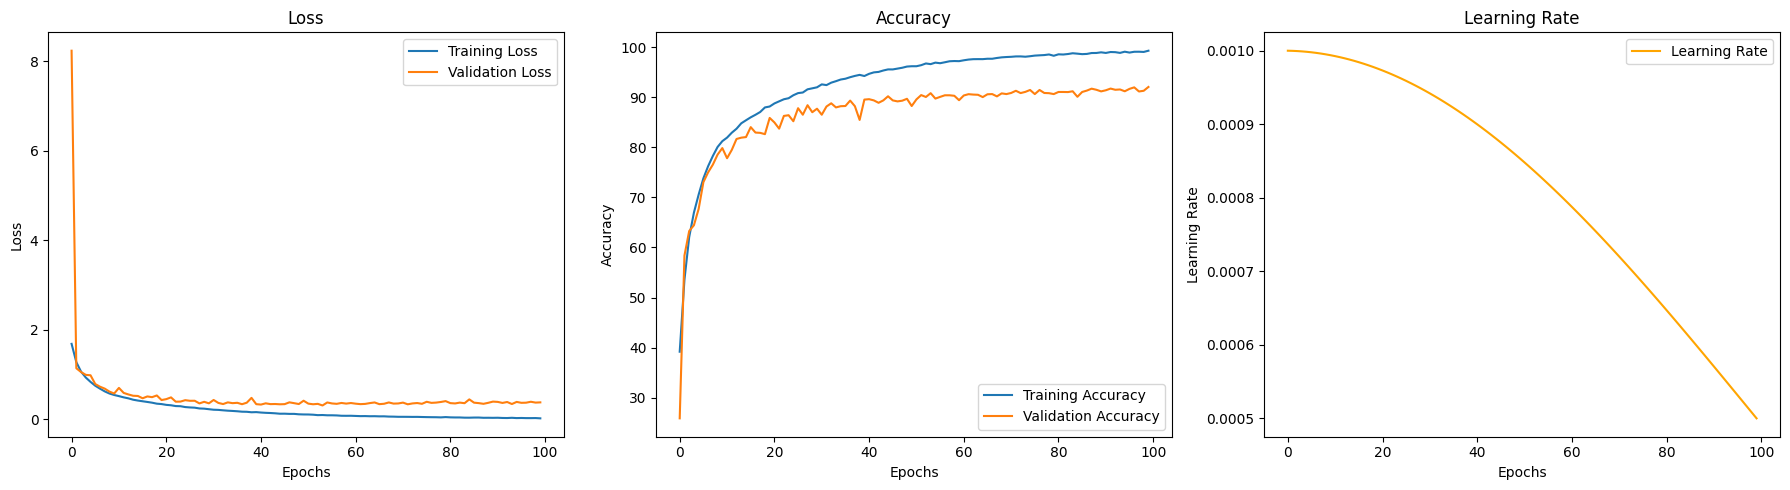

In [16]:
plot_history(history)

In [17]:
%watermark -iv

matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

